# Task 5: Panoramic Image using SIFT
images: boat1, boat2, boat3 from opencv stitching samples (camera panning left to right)

middle image is the base, left and right images are warped onto it

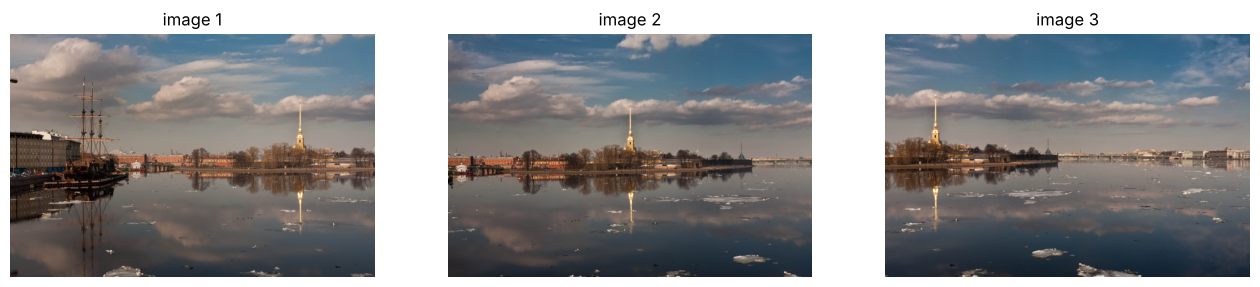

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

files = ["images/boat1.jpg", "images/boat2.jpg", "images/boat3.jpg"]
imgs = []
for f in files:
    im = cv2.imread(f)
    s = 1000 / im.shape[1]
    imgs.append(cv2.resize(im, None, fx=s, fy=s))

plt.figure(figsize=(16, 4))
for i in range(3):
    plt.subplot(1, 3, i + 1); plt.imshow(cv2.cvtColor(imgs[i], cv2.COLOR_BGR2RGB)); plt.title("image " + str(i + 1)); plt.axis("off")
plt.show()

In [2]:
sift = cv2.SIFT_create()
kps = []
dess = []
for im in imgs:
    kp, des = sift.detectAndCompute(cv2.cvtColor(im, cv2.COLOR_BGR2GRAY), None)
    kps.append(kp)
    dess.append(des)
    print("keypoints:", len(kp))

keypoints: 1860
keypoints: 1331


keypoints: 1322


### matching + homography

image 1 -> 2 : 557 matches, 517 inliers


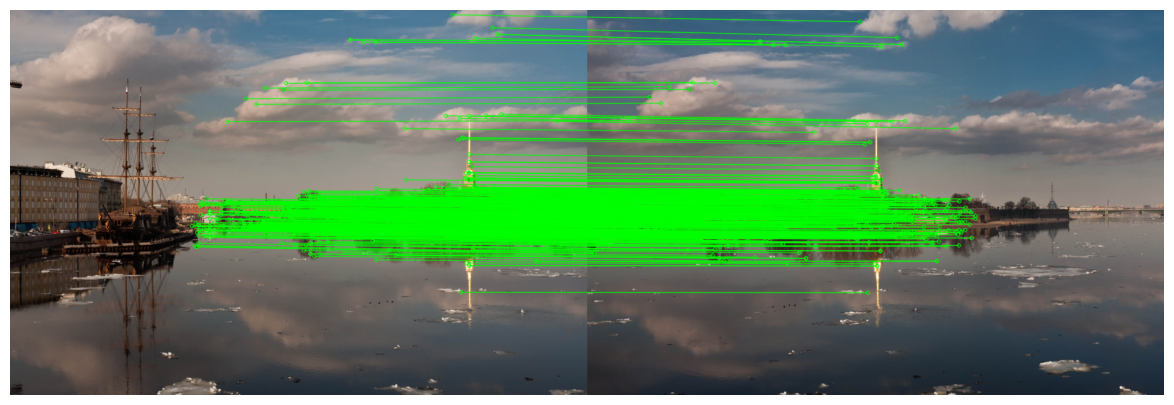

image 3 -> 2 : 451 matches, 360 inliers
[[ 1.24060644e+00  2.05956572e-03 -3.88984205e+02]
 [ 7.92820516e-02  1.15272457e+00 -4.37488552e+01]
 [ 2.46549793e-04 -6.69358065e-06  1.00000000e+00]]


In [3]:
bf = cv2.BFMatcher()

def get_H(a, b, show=False):
    # H that maps image a onto image b
    matches = bf.knnMatch(dess[a], dess[b], k=2)
    good = [m for m, n in matches if m.distance < 0.75 * n.distance]
    src = np.float32([kps[a][m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst = np.float32([kps[b][m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
    H, mask = cv2.findHomography(src, dst, cv2.RANSAC, 4.0)
    print("image", a + 1, "->", b + 1, ":", len(good), "matches,", int(mask.sum()), "inliers")
    if show:
        m_img = cv2.drawMatches(imgs[a], kps[a], imgs[b], kps[b], good, None, matchColor=(0, 255, 0),
                                matchesMask=mask.ravel().tolist(), flags=2)
        plt.figure(figsize=(16, 5)); plt.imshow(cv2.cvtColor(m_img, cv2.COLOR_BGR2RGB)); plt.axis("off"); plt.show()
    return H

H1 = get_H(0, 1, show=True)
H3 = get_H(2, 1)
Hs = [H1, np.eye(3), H3]
print(H1)

### warping
first find how big the final image will be, then shift everything so nothing goes negative

In [4]:
all_pts = []
for im, H in zip(imgs, Hs):
    h, w = im.shape[:2]
    pts = np.float32([[0, 0], [w, 0], [w, h], [0, h]]).reshape(-1, 1, 2)
    all_pts.append(cv2.perspectiveTransform(pts, H))
all_pts = np.concatenate(all_pts)
xmin, ymin = np.int32(all_pts.min(axis=0).ravel() - 0.5)
xmax, ymax = np.int32(all_pts.max(axis=0).ravel() + 0.5)
T = np.array([[1, 0, -xmin], [0, 1, -ymin], [0, 0, 1]], dtype=float)
size = (xmax - xmin, ymax - ymin)
print("panorama size:", size)

warped = []
weights = []
for im, H in zip(imgs, Hs):
    wp = cv2.warpPerspective(im, T @ H, size)
    m = cv2.warpPerspective(np.ones(im.shape[:2], np.uint8), T @ H, size)
    # weight is more at center and less at edges, so the joins look smooth
    wt = cv2.distanceTransform(m, cv2.DIST_L2, 5)
    warped.append(wp.astype(np.float32))
    weights.append(wt)

panorama size: (np.int32(1905), np.int32(811))


### blending + crop

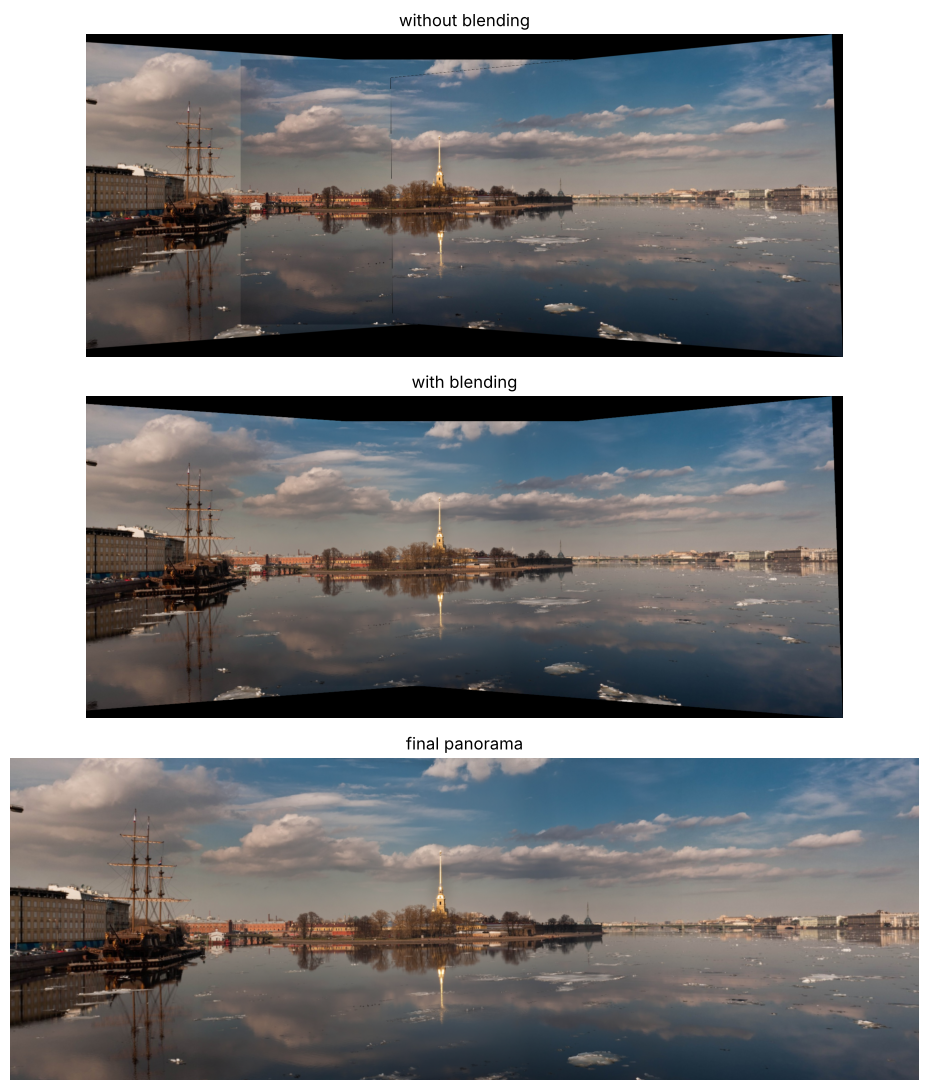

In [5]:
total = weights[0] + weights[1] + weights[2]
pano = np.zeros_like(warped[0])
for wp, wt in zip(warped, weights):
    pano += wp * wt[:, :, None]
pano = (pano / np.maximum(total, 1e-6)[:, :, None]).astype(np.uint8)

# without blending (just pasting) for comparison
simple = np.zeros_like(pano)
for wp in warped:
    m = wp.sum(axis=2) > 0
    simple[m] = wp[m].astype(np.uint8)

# crop black parts
valid = total > 0
rows = np.where(valid.mean(axis=1) > 0.98)[0]
cols = np.where(valid[rows[0]:rows[-1]].mean(axis=0) > 0.98)[0]
final = pano[rows[0]:rows[-1], cols[0]:cols[-1]]
cv2.imwrite("outputs/task5_panorama.jpg", final)

plt.figure(figsize=(18, 11))
plt.subplot(3, 1, 1); plt.imshow(cv2.cvtColor(simple, cv2.COLOR_BGR2RGB)); plt.title("without blending"); plt.axis("off")
plt.subplot(3, 1, 2); plt.imshow(cv2.cvtColor(pano, cv2.COLOR_BGR2RGB)); plt.title("with blending"); plt.axis("off")
plt.subplot(3, 1, 3); plt.imshow(cv2.cvtColor(final, cv2.COLOR_BGR2RGB)); plt.title("final panorama"); plt.axis("off")
plt.tight_layout()
plt.show()

### opencv stitcher (just to compare)

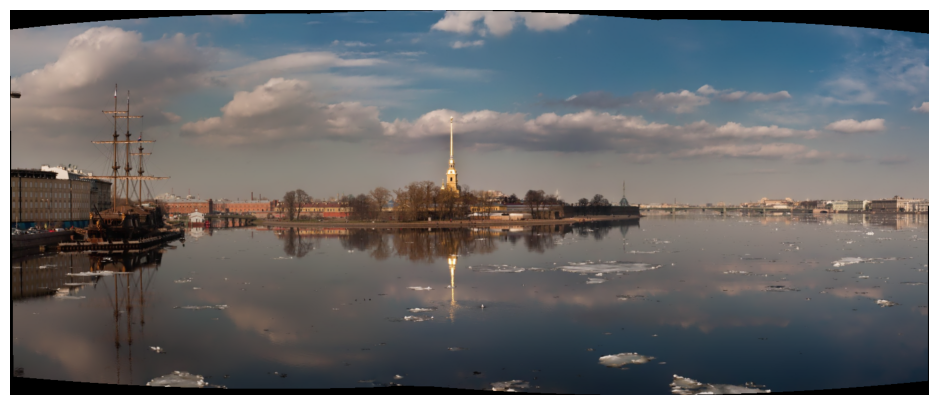

In [6]:
stitcher = cv2.Stitcher_create()
status, auto = stitcher.stitch(imgs)
if status == 0:
    plt.figure(figsize=(18, 5)); plt.imshow(cv2.cvtColor(auto, cv2.COLOR_BGR2RGB)); plt.axis("off"); plt.show()
    cv2.imwrite("outputs/task5_panorama_cv2_stitcher.jpg", auto)
else:
    print("stitcher failed", status)